# Block-permutation diagnostics

Two checks on the block-permutation KS test whose size was verified in `ks_block_permutation.ipynb` and which produced the RAMIP p-value maps in `ks_path_independence_ramip_multi.ipynb`.

1. **Sample-pixel distributions.** For a few pixels (low / mid / high p), compare the *actual* monthly-tas distribution against the *synthetic* samples the block permutation generates: ECDFs of the two observed samples against 200 block-permuted replicates, the autocorrelation function of real vs block-permuted vs iid-shuffled series, and the permutation null of D against the observed D.
2. **Ensemble-pair maps.** Pixel-wise block-permutation p-value maps for pairs of `ssp370` members of the *same* model (CanESM5-1) — same forcing, so every rejection is a false positive. This is the map version of size case 3; a correctly-sized test gives spatially unstructured p-values, uniform on [0,1], with ~5% of land below 0.05.

In [1]:
import os, re, glob
from itertools import combinations

import numpy as np
import xarray as xr
from scipy import stats as sstats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import regionmask

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
from funcs_support import get_params
dir_list = get_params()

RAW     = dir_list['raw'] + 'ramip/'
OTHER   = 'ssp370-126aer'
ANCHOR  = {m: 'ssp370' for m in
           ['CanESM5-1', 'CNRM-ESM2-1', 'EC-Earth3-AerChem', 'MIROC6',
            'MRI-ESM2-0', 'NorESM2-LM', 'UKESM1-0-LL']}
ANCHOR['CESM2'] = 'ssp370-LE'
YEARS   = (2041, 2050)
ALPHA   = 0.05
NDRAWS  = 999
BLOCK   = 12
BP_DIR  = dir_list['aux'] + 'diagnostics/ks_blockperm_ramip/'
out_dir = dir_list['aux'] + '../figures/'


def member_files(mod, exp):
    fns = glob.glob(f'{RAW}{mod}/tas_Amon_{mod}_{exp}_r*.zarr')
    return {re.search(r'_(r\d+i\d+p\d+f\d+)_', f).group(1): f for f in fns}


def window_vals(fn):
    ds = xr.open_zarr(fn, consolidated=False)
    da = ds['tas'].sel(time=(ds.time.dt.year >= YEARS[0]) & (ds.time.dt.year <= YEARS[1]))
    v = da.load().transpose('lat', 'lon', 'time')
    return v.values.reshape(-1, v.sizes['time']), v.lat, v.lon

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from numba import njit, prange, set_num_threads
set_num_threads(16)


@njit
def ks_statistic_sorted(x, y):
    """KS statistic for already-sorted arrays (verbatim from 4-fig_impact_figures.ipynb)."""
    nx = len(x); ny = len(y)
    i = 0; j = 0
    cdfx = 0.0; cdfy = 0.0
    d = 0.0
    while i < nx and j < ny:
        if x[i] <= y[j]:
            i += 1
            cdfx = i / nx
        else:
            j += 1
            cdfy = j / ny
        diff = abs(cdfx - cdfy)
        if diff > d:
            d = diff
    while i < nx:
        i += 1
        cdfx = i / nx
        diff = abs(cdfx - cdfy)
        if diff > d:
            d = diff
    while j < ny:
        j += 1
        cdfy = j / ny
        diff = abs(cdfx - cdfy)
        if diff > d:
            d = diff
    return d


@njit
def ks_block_permutation_test(x, y, block=12, ndraws=999):
    """Block-permutation KS p: Fisher-Yates shuffle reassigns whole `block`-length
    blocks between the samples (size verified in ks_block_permutation.ipynb)."""
    nx = len(x); ny = len(y)
    nbx = nx // block; nby = ny // block
    nb = nbx + nby
    D_obs = ks_statistic_sorted(np.sort(x.copy()), np.sort(y.copy()))
    pool = np.empty(nx + ny, dtype=x.dtype)
    pool[:nx] = x
    pool[nx:] = y
    order = np.arange(nb)
    xperm = np.empty(nx, dtype=x.dtype)
    yperm = np.empty(ny, dtype=x.dtype)
    exceed = 0
    for draw in range(ndraws):
        for i in range(nb - 1, 0, -1):
            j = np.random.randint(i + 1)
            tmp = order[i]; order[i] = order[j]; order[j] = tmp
        for b in range(nbx):
            s = order[b] * block
            xperm[b * block:(b + 1) * block] = pool[s:s + block]
        for b in range(nby):
            s = order[nbx + b] * block
            yperm[b * block:(b + 1) * block] = pool[s:s + block]
        xperm.sort(); yperm.sort()
        if ks_statistic_sorted(xperm, yperm) >= D_obs:
            exceed += 1
    return (exceed + 1) / (ndraws + 1)   # Phipson & Smyth 2010


@njit(parallel=True)
def block_perm_map(A, B, block=12, ndraws=999):
    """p-value per pixel; A, B are (pixels, time)."""
    P = A.shape[0]
    out = np.empty(P)
    for px in prange(P):
        out[px] = ks_block_permutation_test(A[px], B[px], block, ndraws)
    return out


# numpy twin of the shuffle inside the numba kernel, so the diagnostics can look at
# the synthetic samples themselves rather than only the p-value they produce
def block_permute(x, y, block, rng):
    blocks = np.concatenate([x, y]).reshape(-1, block)
    order = rng.permutation(len(blocks))
    nbx = len(x) // block
    return blocks[order[:nbx]].ravel(), blocks[order[nbx:]].ravel()


def acf(x, nlag):
    x = x - x.mean()
    return np.array([1.0] + [np.corrcoef(x[:-k], x[k:])[0, 1] for k in range(1, nlag + 1)])


def ecdf(v):
    xs = np.sort(v)
    return xs, np.arange(1, len(xs) + 1) / len(xs)


# compile + sanity: perm p ~ asymptotic p on iid data
_r = np.random.default_rng(0)
_x, _y = _r.standard_normal((2, 120)), _r.standard_normal((2, 120))
print('iid check  perm:', np.round(block_perm_map(_x, _y, BLOCK, NDRAWS), 3),
      ' asymptotic:', np.round([sstats.kstest(_x[i], _y[i], method='asymp').pvalue
                                for i in range(2)], 3))

iid check  perm: [0.355 0.761]  asymptotic: [0.451 0.66 ]


## 1. Sample pixels: actual vs synthetic block-permuted distributions

Three land pixels of EC-Earth3-AerChem (strongest aerosol signal of the 8 models), run 0, `ssp370` vs `ssp370-126aer`, 2041–2050 monthly tas, picked nearest to block-permutation p = 0.001 / 0.5 / 0.95 from the cached map.

- **Top:** ECDFs of the two observed samples (colour) over 200 block-permuted replicate ECDFs (grey). The replicates are draws from the pooled null, so under H0 the two observed curves should sit inside the grey envelope; a real difference pushes one curve out of it.
- **Middle:** autocorrelation function of the observed series against a block-permuted and an iid-shuffled version. Blocks keep autocorrelation up to the block length (only the between-block joins are randomised); the iid shuffle destroys all of it — that difference is exactly why the permutation null is wider than the iid one.
- **Bottom:** permutation null of the KS statistic D with the observed D marked, against the asymptotic null (`kstwo`) that the classical test uses.

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_blockperm_pixel_diagnostics.png
low  block-perm p=0.001  lat=-30.53  lon=28.83
mid  block-perm p=0.5  lat=-51.58  lon=-60.47
high block-perm p=0.951  lat=-41.05  lon=145.55


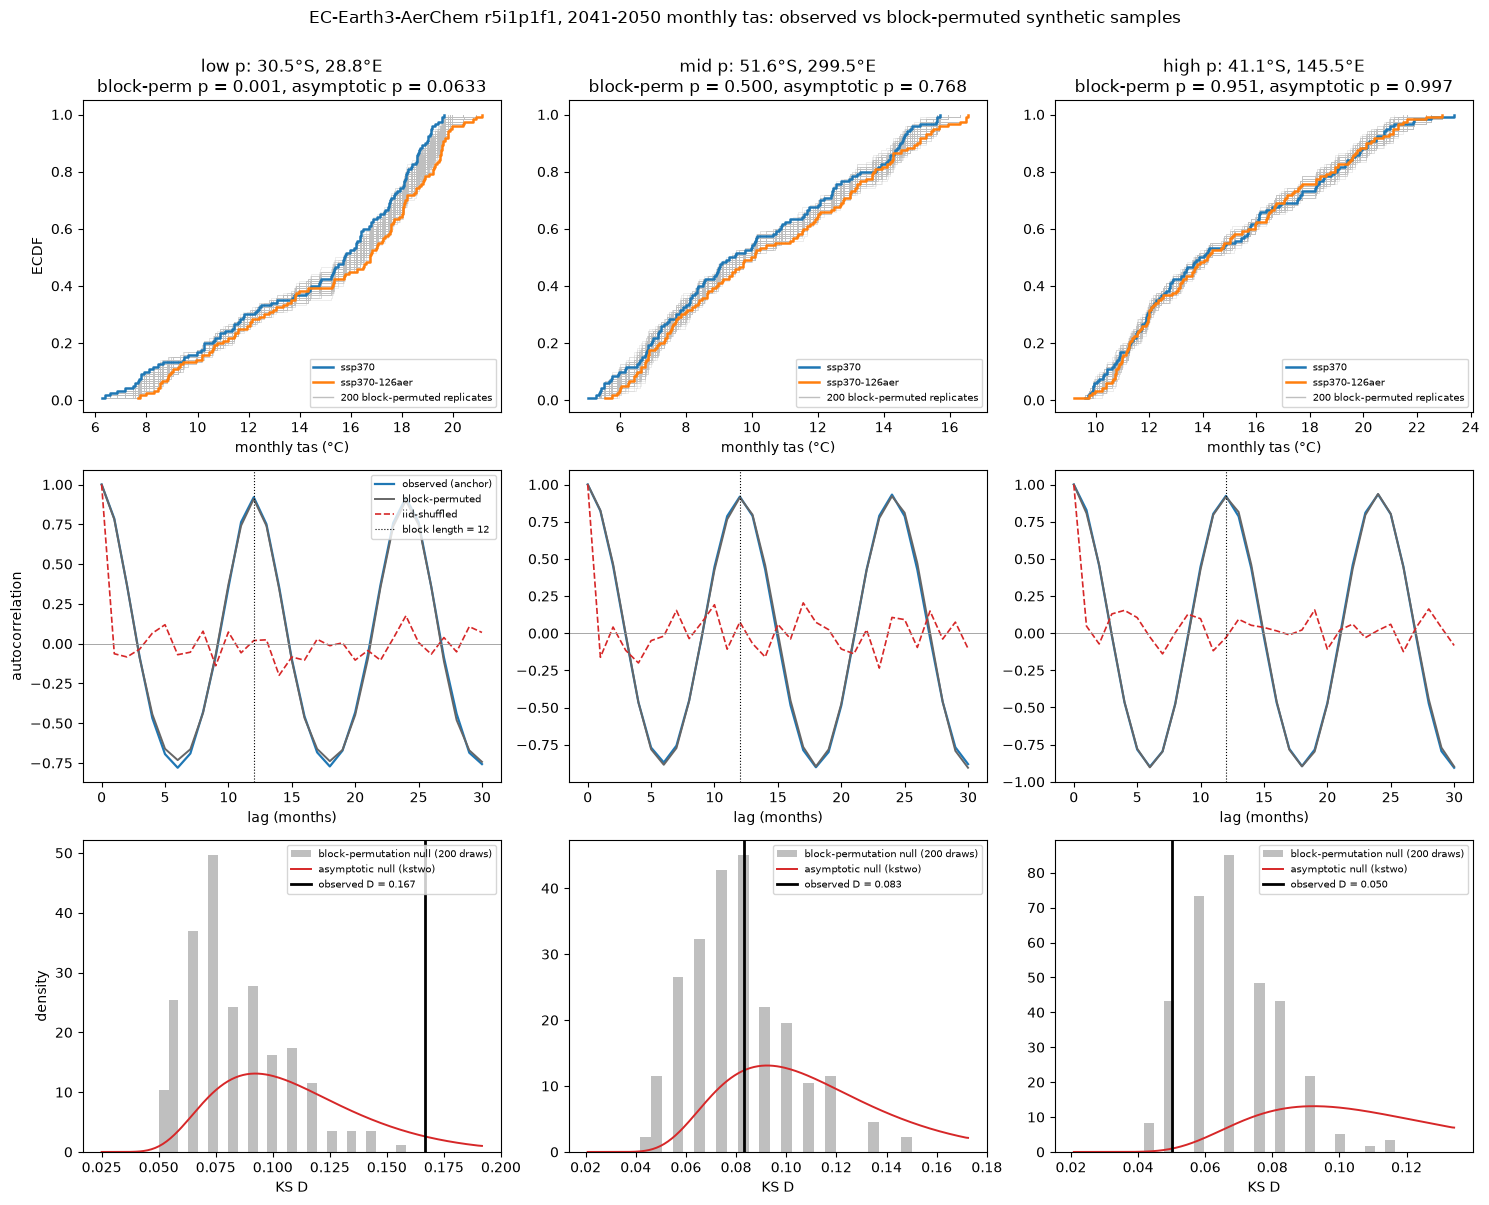

In [3]:
MOD_S = 'EC-Earth3-AerChem'
pv_s  = xr.open_dataarray(f'{BP_DIR}{MOD_S}.nc').load()
run_s = str(pv_s.run.values[0])
p0    = pv_s.isel(run=0)

lm_s   = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(p0.lon, p0.lat)
land_s = (lm_s == 0).values & (p0.lat > -60).values[:, None]      # land, no Antarctica

picks = {}
for name, t in {'low': 0.001, 'mid': 0.5, 'high': 0.95}.items():
    masked = np.where(land_s & np.isfinite(p0.values), np.abs(p0.values - t), np.inf)
    picks[name] = np.unravel_index(np.argmin(masked), p0.shape)


def pixel_series(exp, iy, ix):
    ds = xr.open_zarr(member_files(MOD_S, exp)[run_s], consolidated=False)
    da = ds['tas'].sel(time=(ds.time.dt.year >= YEARS[0]) & (ds.time.dt.year <= YEARS[1]))
    return da.isel(lat=iy, lon=ix).load().values.astype(float) - 273.15


NREP, NLAG = 200, 30
rng = np.random.default_rng(11)

fig, axs = plt.subplots(3, 3, figsize=(15, 12))
for col, (name, (iy, ix)) in enumerate(picks.items()):
    a = pixel_series(ANCHOR[MOD_S], iy, ix)
    b = pixel_series(OTHER, iy, ix)
    lat_v, lon_v = float(p0.lat[iy]), float(p0.lon[ix])
    loc = f'{abs(lat_v):.1f}°{"N" if lat_v >= 0 else "S"}, {lon_v % 360:.1f}°E'
    p_bp = float(p0.values[iy, ix])
    ks   = sstats.kstest(a, b, method='asymp')

    # --- ECDFs: observed vs synthetic block-permuted replicates
    ax = axs[0, col]
    Dnull = np.empty(NREP)
    for i in range(NREP):
        xp, yp = block_permute(a, b, BLOCK, rng)
        for v in (xp, yp):
            xs, ys = ecdf(v)
            ax.step(xs, ys, where='post', color='0.75', lw=0.4, alpha=0.5, zorder=1)
        Dnull[i] = ks_statistic_sorted(np.sort(xp), np.sort(yp))
    for v, lab, cl in [(a, ANCHOR[MOD_S], 'tab:blue'), (b, OTHER, 'tab:orange')]:
        xs, ys = ecdf(v)
        ax.step(xs, ys, where='post', color=cl, lw=1.8, label=lab, zorder=3)
    ax.plot([], [], color='0.75', lw=1, label=f'{NREP} block-permuted replicates')
    ax.set_title(f'{name} p: {loc}\nblock-perm p = {p_bp:.3f}, asymptotic p = {ks.pvalue:.3g}')
    ax.set_xlabel('monthly tas (°C)')
    if col == 0:
        ax.set_ylabel('ECDF')
    ax.legend(fontsize=7, loc='lower right')

    # --- autocorrelation: real vs block-permuted vs iid-shuffled
    ax = axs[1, col]
    xp, _ = block_permute(a, b, BLOCK, rng)
    ax.plot(acf(a, NLAG), color='tab:blue', lw=1.6, label='observed (anchor)')
    ax.plot(acf(xp, NLAG), color='0.4', lw=1.4, label='block-permuted')
    ax.plot(acf(rng.permutation(a), NLAG), color='tab:red', lw=1.2, ls='--',
            label='iid-shuffled')
    ax.axvline(BLOCK, color='k', lw=0.8, ls=':', label=f'block length = {BLOCK}')
    ax.axhline(0, color='0.6', lw=0.6)
    ax.set_xlabel('lag (months)')
    if col == 0:
        ax.set_ylabel('autocorrelation')
        ax.legend(fontsize=7)

    # --- permutation null of D vs asymptotic null
    ax = axs[2, col]
    ax.hist(Dnull, bins=25, density=True, color='0.75',
            label=f'block-permutation null ({NREP} draws)')
    grid = np.linspace(Dnull.min() * 0.5, max(Dnull.max(), ks.statistic) * 1.15, 200)
    en = round(len(a) * len(b) / (len(a) + len(b)))
    ax.plot(grid, np.gradient(1 - sstats.kstwo.sf(grid, en), grid),
            color='tab:red', lw=1.4, label='asymptotic null (kstwo)')
    ax.axvline(ks.statistic, color='k', lw=2, label=f'observed D = {ks.statistic:.3f}')
    ax.set_xlabel('KS D')
    if col == 0:
        ax.set_ylabel('density')
    ax.legend(fontsize=7)

fig.suptitle(f'{MOD_S} {run_s}, {YEARS[0]}-{YEARS[1]} monthly tas: '
             f'observed vs block-permuted synthetic samples', y=1.0)
fig.tight_layout()
fig.savefig(out_dir + 'ks_blockperm_pixel_diagnostics.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_blockperm_pixel_diagnostics.png')
for name, (iy, ix) in picks.items():
    print(f'{name:4s} block-perm p={p0.values[iy, ix]:.4g}  '
          f'lat={float(p0.lat[iy]):.2f}  lon={float(p0.lon[ix]):.2f}')

## 2. Ensemble-pair maps (null true everywhere)

CanESM5-1 `ssp370`, all 10 members ⇒ 45 pairs, full grid (64×128), 2041–2050 monthly tas. Same model, same forcing, different initial conditions: the two samples are draws from the *same* distribution at every pixel, so a correctly-sized test should give p ~ Uniform[0,1] with no spatial structure and 5% of pixels below 0.05.

Both tests are computed on the same pairs so the maps are directly comparable to the anchor-vs-126aer maps in `ks_path_independence_ramip_multi.ipynb`.

In [4]:
EP_DIR = dir_list['aux'] + 'diagnostics/ks_blockperm_enspairs/'
os.makedirs(EP_DIR, exist_ok=True)
MOD_E = 'CanESM5-1'
cache_fn = f'{EP_DIR}{MOD_E}.nc'


def ks_fast(a1, a2):
    """asymptotic p per pixel (as in ks_path_independence_maps.ipynb)"""
    P, n1 = a1.shape; n2 = a2.shape[1]
    z = np.concatenate([a1, a2], axis=1)
    order = np.argsort(z, axis=1, kind='stable')
    zs = np.take_along_axis(z, order, axis=1)
    ind = np.where(order < n1, 1.0 / n1, -1.0 / n2)
    cd = np.cumsum(ind, axis=1)
    valid = np.ones_like(cd, dtype=bool)
    valid[:, :-1] = zs[:, 1:] != zs[:, :-1]
    D = np.abs(np.where(valid, cd, 0.0)).max(axis=1)
    en = int(np.round(n1 * n2 / (n1 + n2)))
    uD, inv = np.unique(D, return_inverse=True)
    return np.clip(sstats.kstwo.sf(uD, en), 0, 1)[inv]


if os.path.exists(cache_fn):
    ep = xr.open_dataset(cache_fn).load()
    print(f'loaded cache: {ep.sizes["pair"]} pairs')
else:
    fns = member_files(MOD_E, 'ssp370')
    runs = sorted(fns, key=lambda m: [int(x) for x in re.findall(r'\d+', m)])
    members = {}
    for r in runs:
        members[r], lat_e, lon_e = window_vals(fns[r])
    print(f'{MOD_E}: {len(runs)} ssp370 members, {members[runs[0]].shape} (pixels, months)')

    pairs, p_bp, p_as = [], [], []
    for r1, r2 in combinations(runs, 2):
        A, B = members[r1], members[r2]
        p_bp.append(block_perm_map(A, B, BLOCK, NDRAWS).reshape(len(lat_e), len(lon_e)))
        p_as.append(ks_fast(A, B).reshape(len(lat_e), len(lon_e)))
        pairs.append(f'{r1}|{r2}')
        print(f'  {pairs[-1]} done', flush=True)

    dims = ('pair', 'lat', 'lon')
    coords = {'pair': pairs, 'lat': lat_e, 'lon': lon_e}
    ep = xr.Dataset({'p_blockperm': (dims, np.stack(p_bp)),
                     'p_asymptotic': (dims, np.stack(p_as))}, coords=coords)
    ep.to_netcdf(cache_fn)
    print('saved', cache_fn)

loaded cache: 45 pairs


CanESM5-1 ssp370, 45 same-forcing member pairs, 1959 land pixels (no Antarctica) — every rejection is a false positive
  land fraction p<0.05:  block-perm 0.057   asymptotic 0.008   (nominal 0.05)
  per-pair range, block-perm: 0.014 - 0.170


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_blockperm_ensemble_pairs.png


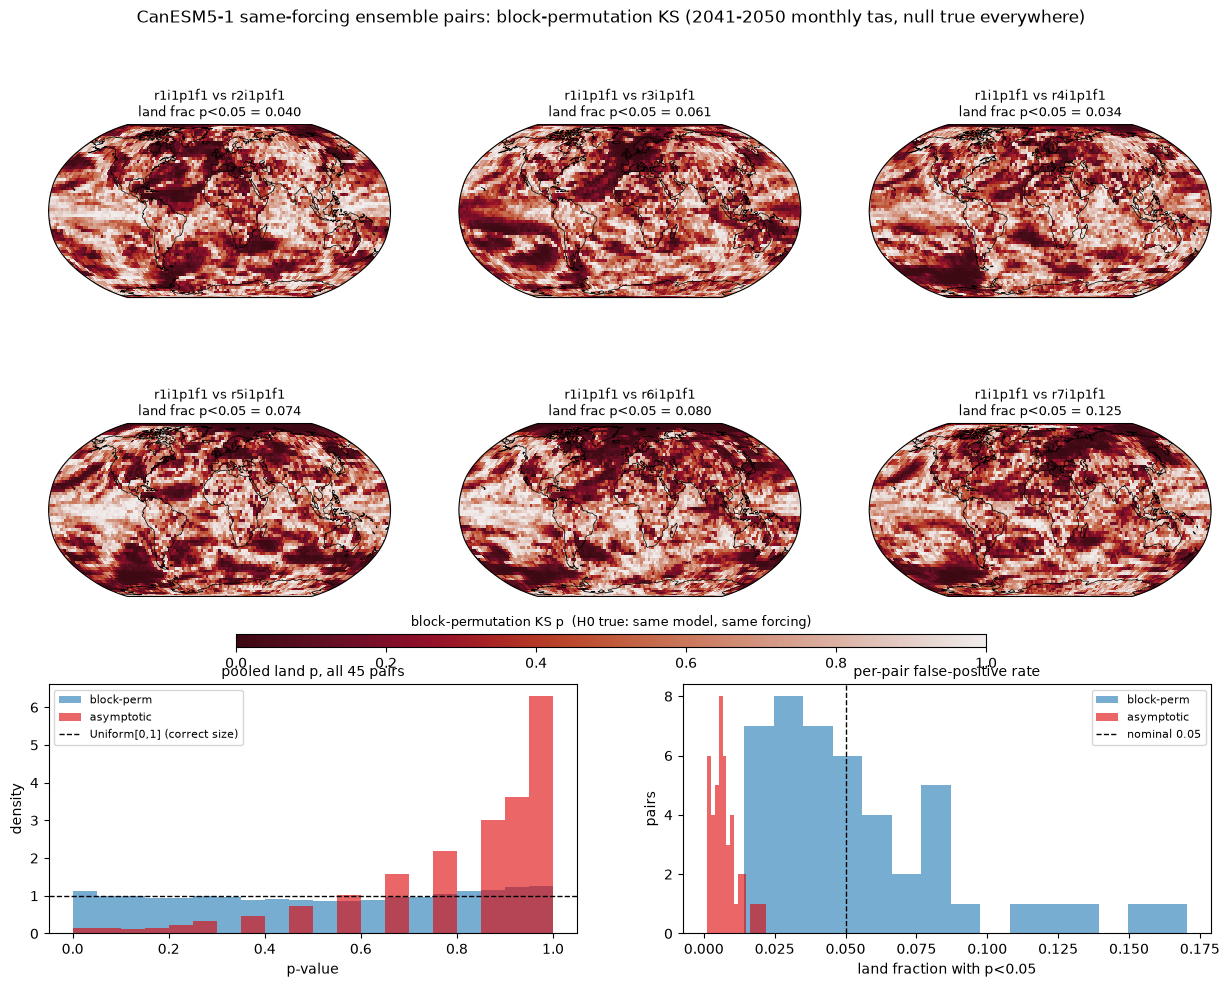

In [5]:
lm_e = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(ep.lon, ep.lat)
land_e = (lm_e == 0).values & (ep.lat > -60).values[:, None]

lp_bp = ep['p_blockperm'].values[:, land_e]
lp_as = ep['p_asymptotic'].values[:, land_e]
print(f'{MOD_E} ssp370, {ep.sizes["pair"]} same-forcing member pairs, '
      f'{land_e.sum()} land pixels (no Antarctica) — every rejection is a false positive')
print(f'  land fraction p<{ALPHA}:  block-perm {(lp_bp < ALPHA).mean():.3f}   '
      f'asymptotic {(lp_as < ALPHA).mean():.3f}   (nominal {ALPHA})')
print(f'  per-pair range, block-perm: {(lp_bp < ALPHA).mean(axis=1).min():.3f} - '
      f'{(lp_bp < ALPHA).mean(axis=1).max():.3f}')

fig = plt.figure(figsize=(15, 11))
for i in range(6):
    ax = fig.add_subplot(3, 3, i + 1, projection=ccrs.Robinson())
    v = ep['p_blockperm'].isel(pair=i)
    im = ax.pcolormesh(ep.lon, ep.lat, v, transform=ccrs.PlateCarree(),
                       cmap=cmocean.cm.amp_r, vmin=0, vmax=1)
    ax.coastlines(lw=0.5)
    frac = (v.values[land_e] < ALPHA).mean()
    ax.set_title(f'{str(ep.pair.values[i]).replace("|", " vs ")}\n'
                 f'land frac p<{ALPHA} = {frac:.3f}', fontsize=9)
cax = fig.add_axes([0.25, 0.37, 0.5, 0.012])
fig.colorbar(im, cax=cax, orientation='horizontal')
cax.set_title('block-permutation KS p  (H0 true: same model, same forcing)', fontsize=9)

# pooled p distribution: should be uniform for a correctly-sized test
ax = fig.add_subplot(3, 2, 5)
bins = np.linspace(0, 1, 21)
ax.hist(lp_bp.ravel(), bins=bins, density=True, alpha=0.6,
        color='#1f77b4', label='block-perm')
ax.hist(lp_as.ravel(), bins=bins, density=True, alpha=0.6,
        color='#df0000', label='asymptotic')
ax.axhline(1, color='k', ls='--', lw=1, label='Uniform[0,1] (correct size)')
ax.set_xlabel('p-value'); ax.set_ylabel('density')
ax.set_title(f'pooled land p, all {ep.sizes["pair"]} pairs', fontsize=10)
ax.legend(fontsize=8)

ax = fig.add_subplot(3, 2, 6)
for v, lab, cl in [(lp_bp, 'block-perm', '#1f77b4'), (lp_as, 'asymptotic', '#df0000')]:
    ax.hist((v < ALPHA).mean(axis=1), bins=15, alpha=0.6, color=cl, label=lab)
ax.axvline(ALPHA, color='k', ls='--', lw=1, label=f'nominal {ALPHA}')
ax.set_xlabel(f'land fraction with p<{ALPHA}'); ax.set_ylabel('pairs')
ax.set_title('per-pair false-positive rate', fontsize=10)
ax.legend(fontsize=8)

fig.suptitle(f'{MOD_E} same-forcing ensemble pairs: block-permutation KS '
             f'({YEARS[0]}-{YEARS[1]} monthly tas, null true everywhere)', y=0.95)
fig.savefig(out_dir + 'ks_blockperm_ensemble_pairs.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_blockperm_ensemble_pairs.png')